In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dasgroup/rba-dataset/LICENSE
/kaggle/input/datasets/dasgroup/rba-dataset/README.md
/kaggle/input/datasets/dasgroup/rba-dataset/RESULTS.md
/kaggle/input/datasets/dasgroup/rba-dataset/rba-dataset.csv
/kaggle/input/datasets/dasgroup/rba-dataset/images/rq1-general.png
/kaggle/input/datasets/dasgroup/rba-dataset/images/rq1-login-frequency.png
/kaggle/input/datasets/dasgroup/rba-dataset/images/rtts-global.png
/kaggle/input/datasets/dasgroup/rba-dataset/images/login-overview.png
/kaggle/input/datasets/dasgroup/rba-dataset/images/rtts-continents.png
/kaggle/input/datasets/dasgroup/rba-dataset/images/rq6-rtt-0_999.png
/kaggle/input/datasets/dasgroup/rba-dataset/images/rq2-attack-data.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest, proportion_confint, proportion_effectsize
np.random.seed(42)   # supaya hasil acak selalu sama tiap dijalankan

print("Sel 1 OK - semua library siap!")

Sel 1 OK - semua library siap!


In [3]:

csv_path = "/kaggle/input/datasets/dasgroup/rba-dataset/rba-dataset.csv"

# Baca 300.000 baris pertama saja 
df = pd.read_csv(csv_path, nrows=300000)

print("Sel 2 OK")
print("Jumlah baris :", len(df))
print("Jumlah kolom :", df.shape[1])

Sel 2 OK
Jumlah baris : 300000
Jumlah kolom : 16


In [4]:
print("Nama-nama kolom:")
print(df.columns.tolist())
df.head()

Nama-nama kolom:
['index', 'Login Timestamp', 'User ID', 'Round-Trip Time [ms]', 'IP Address', 'Country', 'Region', 'City', 'ASN', 'User Agent String', 'Browser Name and Version', 'OS Name and Version', 'Device Type', 'Login Successful', 'Is Attack IP', 'Is Account Takeover']


,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
0,0,2020-02-03 12:43:30.772,-4324475583306591935,NaN,10.0.65.171,NO,-,-,29695,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Firefox 20.0.0.1618,iOS 13.4,mobile,False,False,False
1,1,2020-02-03 12:43:43.549,-4324475583306591935,NaN,194.87.207.6,AU,-,-,60117,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile 46.0.2490,Android 4.1,mobile,False,False,False
2,2,2020-02-03 12:43:55.873,-3284137479262433373,NaN,81.167.144.58,NO,Vestland,Urangsvag,29695,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,True,False,False
3,3,2020-02-03 12:43:56.180,-4324475583306591935,NaN,170.39.78.152,US,-,-,393398,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile WebView 85.0.4183,Android 4.1,mobile,False,False,False
4,4,2020-02-03 12:43:59.396,-4618854071942621186,NaN,10.0.0.47,US,Virginia,Ashburn,398986,Mozilla/5.0 (Linux; U; Android 2.2) Build/NMA...,Chrome Mobile WebView 85.0.4183,Android 2.2,mobile,False,True,False


In [5]:
# Rapikan kolom Is Attack IP agar terbaca seragam (True/False)
df['Is Attack IP'] = df['Is Attack IP'].astype(str).str.strip().str.lower().isin(['true', '1', 'yes'])

# Definisi (versi tajam): login mencurigakan = login dari IP penyerang
df['suspicious'] = df['Is Attack IP'].astype(int)

print("Sel 4 OK (definisi diperbarui)")
print("Persentase login mencurigakan keseluruhan:",
      round(df['suspicious'].mean() * 100, 2), "%")

Sel 4 OK (definisi diperbarui)
Persentase login mencurigakan keseluruhan: 9.22 %


In [6]:
# Bagi acak 50:50 ke dua grup
df['group'] = np.random.choice(['A', 'B'], size=len(df))   # A = TANPA notifikasi, B = DENGAN notifikasi

# SIMULASI: anggap notifikasi berhasil mencegah 20% login mencurigakan di grup B
mask = (df['group'] == 'B') & (df['suspicious'] == 1)
prevented = np.random.rand(mask.sum()) < 0.20
idx = df[mask].index[prevented]
df.loc[idx, 'suspicious'] = 0

print("Sel 5 OK - grup A & B dibuat, efek notifikasi disimulasikan.")
print(df['group'].value_counts())

Sel 5 OK - grup A & B dibuat, efek notifikasi disimulasikan.
group
B    150174
A    149826
Name: count, dtype: int64


In [7]:
tabel = df.groupby('group')['suspicious'].agg(total='count', mencurigakan='sum')
tabel['proporsi_%'] = (tabel['mencurigakan'] / tabel['total'] * 100).round(2)
print(tabel)

# Simpan angka untuk dipakai di uji statistik (urutan: [A, B])
x = tabel['mencurigakan'].values
n = tabel['total'].values

        total  mencurigakan  proporsi_%
group                                  
A      149826         13841        9.24
B      150174         11048        7.36


# **UJI HIPOTESIS**

In [8]:
# Uji dua proporsi, satu arah (menguji apakah A lebih besar dari B)
z, p_value = proportions_ztest(x, n, alternative='larger')

print("Proporsi grup A (tanpa notifikasi) :", round(x[0]/n[0]*100, 2), "%")
print("Proporsi grup B (dengan notifikasi):", round(x[1]/n[1]*100, 2), "%")
print("Nilai Z :", round(z, 3))
print("p-value :", p_value)
print()
if p_value < 0.05:
    print(">> p-value < 0.05  =>  TOLAK H0: notifikasi SIGNIFIKAN menurunkan login mencurigakan.")
else:
    print(">> p-value >= 0.05 =>  GAGAL tolak H0: belum ada bukti notifikasi berpengaruh.")

Proporsi grup A (tanpa notifikasi) : 9.24 %
Proporsi grup B (dengan notifikasi): 7.36 %
Nilai Z : 18.678
p-value : 3.7083081848182186e-78

>> p-value < 0.05  =>  TOLAK H0: notifikasi SIGNIFIKAN menurunkan login mencurigakan.


# **Confidence Interval**

In [9]:
for nama, xi, ni in zip(['A', 'B'], x, n):
    lo, hi = proportion_confint(xi, ni, alpha=0.05, method='wilson')
    print(f"Grup {nama}: 95% CI = [{lo*100:.2f}% , {hi*100:.2f}%]")

pA, pB = x[0]/n[0], x[1]/n[1]
print("Penurunan absolut :", round((pA - pB) * 100, 2), "poin persen")
print("Penurunan relatif :", round((pA - pB) / pA * 100, 1), "%")
print("Cohen's h         :", round(proportion_effectsize(pA, pB), 3))

Grup A: 95% CI = [9.09% , 9.39%]
Grup B: 95% CI = [7.23% , 7.49%]
Penurunan absolut : 1.88 poin persen
Penurunan relatif : 20.4 %
Cohen's h         : 0.068


# **Grafik Perbandingan** 

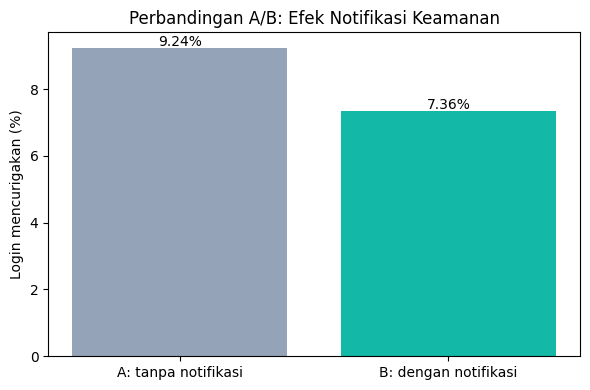

In [10]:
plt.figure(figsize=(6, 4))
plt.bar(['A: tanpa notifikasi', 'B: dengan notifikasi'],
        [pA*100, pB*100], color=['#94a3b8', '#14b8a6'])
plt.ylabel('Login mencurigakan (%)')
plt.title('Perbandingan A/B: Efek Notifikasi Keamanan')
for i, v in enumerate([pA*100, pB*100]):
    plt.text(i, v + 0.05, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

# **Uji A/A** 

In [11]:
# Definisi mencurigakan ASLI (tanpa efek notifikasi) diambil ulang dari kolom Is Attack IP
susp_asli = df['Is Attack IP'].astype(int).values

# Bagi ulang acak, TANPA simulasi efek
grp_aa = np.random.choice(['A', 'B'], size=len(df))
x_aa = [susp_asli[grp_aa == 'A'].sum(), susp_asli[grp_aa == 'B'].sum()]
n_aa = [(grp_aa == 'A').sum(), (grp_aa == 'B').sum()]

z_aa, p_aa = proportions_ztest(x_aa, n_aa, alternative='two-sided')
print("UJI A/A (kontrol vs kontrol, tanpa notifikasi)")
print("p-value :", round(p_aa, 4))
print(">> Diharapkan TIDAK signifikan (p >= 0.05) => uji tidak asal menolak H0.")

UJI A/A (kontrol vs kontrol, tanpa notifikasi)
p-value : 0.2071
>> Diharapkan TIDAK signifikan (p >= 0.05) => uji tidak asal menolak H0.


# **Selang kepercayaan untuk SELISIH**

In [12]:
pA, pB = x[0]/n[0], x[1]/n[1]
diff = pA - pB
se = np.sqrt(pA*(1-pA)/n[0] + pB*(1-pB)/n[1])
lo, hi = diff - 1.96*se, diff + 1.96*se

print(f"Selisih proporsi (A - B) : {diff*100:.2f} poin persen")
print(f"95% CI selisih           : [{lo*100:.2f}% , {hi*100:.2f}%]")
print(">> Karena selang TIDAK memuat 0, penurunan terbukti nyata pada taraf 5%.")

Selisih proporsi (A - B) : 1.88 poin persen
95% CI selisih           : [1.68% , 2.08%]
>> Karena selang TIDAK memuat 0, penurunan terbukti nyata pada taraf 5%.


# **Uji ketahanan**

In [13]:
hasil = []
for seed in range(20):
    rng = np.random.default_rng(seed)
    g = rng.choice(['A', 'B'], size=len(df))
    s = df['Is Attack IP'].astype(int).values.copy()
    mB = np.where((g == 'B') & (s == 1))[0]
    s[mB[rng.random(len(mB)) < 0.20]] = 0   # suntik 20% ke B
    xx = [s[g == 'A'].sum(), s[g == 'B'].sum()]
    nn = [(g == 'A').sum(), (g == 'B').sum()]
    _, pp = proportions_ztest(xx, nn, alternative='larger')
    hasil.append(pp < 0.05)

print(f"Dari 20 pengulangan acak, {sum(hasil)}/20 menolak H0.")
print(">> Kesimpulan stabil, tidak bergantung pada satu kebetulan pembagian grup.")

Dari 20 pengulangan acak, 20/20 menolak H0.
>> Kesimpulan stabil, tidak bergantung pada satu kebetulan pembagian grup.


# **Cek asumsi uji**

In [14]:
print("Cek asumsi (tiap sel harus >= 10):")
for nama, xi, ni in zip(['A', 'B'], x, n):
    gagal = ni - xi
    ok = "OK" if min(xi, gagal) >= 10 else "TIDAK MEMENUHI"
    print(f"  Grup {nama}: mencurigakan={xi}, tidak={gagal} -> {ok}")

Cek asumsi (tiap sel harus >= 10):
  Grup A: mencurigakan=13841, tidak=135985 -> OK
  Grup B: mencurigakan=11048, tidak=139126 -> OK


# **Uji Chi-square**

In [15]:
from scipy.stats import chi2_contingency
tabel_2x2 = [[x[0], n[0]-x[0]], [x[1], n[1]-x[1]]]
chi2, p_chi, dof, _ = chi2_contingency(tabel_2x2, correction=False)
print("Chi-square :", round(chi2, 2), "| p-value:", p_chi)
print("Cek: Z^2 =", round(z**2, 2), "(harus mirip chi-square)")

Chi-square : 348.88 | p-value: 7.41661636963565e-78
Cek: Z^2 = 348.88 (harus mirip chi-square)


# **Power analysis**

In [16]:
from statsmodels.stats.power import NormalIndPower
h = proportion_effectsize(pA, pB)
power = NormalIndPower().power(effect_size=abs(h), nobs1=n[0],
                               ratio=n[1]/n[0], alpha=0.05, alternative='larger')
n_need = NormalIndPower().solve_power(effect_size=abs(h), power=0.8,
                                      alpha=0.05, alternative='larger')
print("Statistical power     :", round(power, 3), "(mendekati 1 = sangat baik)")
print("Sampel minimal/grup   :", int(np.ceil(n_need)), "(untuk power 0.8)")

Statistical power     : 1.0 (mendekati 1 = sangat baik)
Sampel minimal/grup   : 2651 (untuk power 0.8)


# **Grafik dengan error bar**

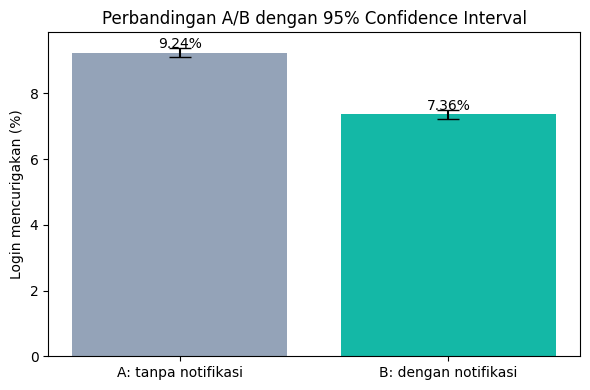

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
rates, errs = [pA*100, pB*100], []
for xi, ni in zip(x, n):
    lo, hi = proportion_confint(xi, ni, method='wilson')
    errs.append([(xi/ni - lo)*100, (hi - xi/ni)*100])
errs = np.array(errs).T
ax.bar(['A: tanpa notifikasi', 'B: dengan notifikasi'], rates,
       yerr=errs, capsize=8, color=['#94a3b8', '#14b8a6'])
ax.set_ylabel('Login mencurigakan (%)')
ax.set_title('Perbandingan A/B dengan 95% Confidence Interval')
for i, v in enumerate(rates):
    ax.text(i, v + 0.15, f'{v:.2f}%', ha='center')
plt.tight_layout(); plt.show()